# Fix: Cropland (3.B.2) discontinuity between 2018 and 2019 in BAU

## Symptom

In the Tableau dashboard, AFOLU subsector **3.B.2 - Cropland** drops from **-0.374 MtCO2e** (NIR historical, 2018) to **-4.50 MtCO2e** in 2019 under BAU (and LEDS), and stays there flat for the rest of the horizon. A **~12x** jump in a single year has no physical basis — it is an input-data artifact.

## Root cause

In the active input (`sisepuede_raw_inputs_recalibrated_electricity_trns_improved_cement.csv`), the Markov transition matrix `pij_lndu_*_to_*` has a systematic anomaly at **time_period=3 (year 2018)**:

- All `pij_lndu_<source>_to_croplands` columns are **zero (or ~0)** in 2018.
- The corresponding probability mass was redistributed — most of it ended up in `pij_lndu_<source>_to_shrublands`.
- Each row still sums to ~1.0 (matrix is still stochastic), so the bug is invisible to elementary checks.
- 2016, 2017 and 2019+ all have normal `to_croplands` values (order 0.005-0.012).

Because SISEPUEDE consumes this matrix directly, the area converted to cropland in 2018 collapses to ~0 ha, then jumps back to ~22,000-35,000 ha in 2019 — producing an explosive jump in `emission_co2e_co2_lndu_conversion_*_to_croplands`. The intertemporal rescaling (`intertemporal_decomposition.r`) pins the 2018 aggregate to the inventory (-0.374), but the 2018->2019 percent change is several orders of magnitude and propagates as-is through the projection horizon.

Year **2015 (time_period=0)** shows the same anomaly, but since the dashboard only displays NIR historical up to 2018 and BAU from 2019 onward, that second anomaly is not visible. It is documented below as a follow-up; the fix here only touches 2018.

## Proposed fix

Replace the entire 2018 Markov row with the **average of 2017 and 2019** values for every `pij_lndu_*` variable, then renormalize per source-state so each row sums to exactly 1.0. This:

1. Removes the artificial zero in `to_croplands` 2018.
2. Preserves the stochastic property of the matrix.
3. Is minimally invasive: only one year of the input is modified.
4. After re-running the model, the 2018->inventory rescaling produces a normal deviation factor, and the 2018->2019 jump disappears.

In [25]:
from pathlib import Path
from datetime import datetime
import shutil
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt

NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR.parent.parent  # notebooks/<sector>/ -> ssp_modeling/
INPUT_DIR = REPO_ROOT / 'input_data'
CONFIG_PATH = NB_DIR.parent / 'config_files' / 'config.yaml'

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

ACTIVE_CSV = INPUT_DIR / cfg['ssp_input_file_name']
print(f'Active input: {ACTIVE_CSV.name}')
print(f'Exists: {ACTIVE_CSV.exists()}')

df = pd.read_csv(ACTIVE_CSV)
print(f'Rows: {len(df)}  Cols: {df.shape[1]}')
assert (df['year'] == df['time_period'] + 2015).all(), 'year != time_period + 2015'
print('time_period <-> year sanity OK (year = time_period + 2015)')

Active input: sisepuede_raw_inputs_recalibrated_electricity_trns_improved_cement.csv
Exists: True
Rows: 56  Cols: 2442
time_period <-> year sanity OK (year = time_period + 2015)


## 1) Diagnosis BEFORE the fix

### 1a) The jump in decomposed emissions (post-rescaling)

In [26]:
TABLEAU_DATA = REPO_ROOT / 'tableau' / 'data' / 'decomposed_emissions_morocco_2018.csv'
tab = pd.read_csv(TABLEAU_DATA)
crop = tab[tab['subsector'] == '3.B.2 - Cropland'].sort_values(['strategy', 'Year'])
print(crop[['strategy', 'Year', 'value', 'source']].to_string(index=False))

        strategy  Year     value    source
      Historical  2010 -0.363600       NIR
      Historical  2012 -0.497900       NIR
      Historical  2014 -0.303300       NIR
      Historical  2016 -0.252800       NIR
      Historical  2018 -0.374200       NIR
            LEDS  2018 -0.374200 SISEPUEDE
            LEDS  2019 -0.299893 SISEPUEDE
            LEDS  2020 -0.298587 SISEPUEDE
            LEDS  2021 -0.297540 SISEPUEDE
            LEDS  2022 -0.296453 SISEPUEDE
            LEDS  2023 -0.295221 SISEPUEDE
            LEDS  2024 -0.294178 SISEPUEDE
            LEDS  2025 -0.293135 SISEPUEDE
            LEDS  2026 -0.292094 SISEPUEDE
            LEDS  2027 -0.291056 SISEPUEDE
            LEDS  2028 -0.290021 SISEPUEDE
            LEDS  2029 -0.288988 SISEPUEDE
            LEDS  2030 -0.287957 SISEPUEDE
            LEDS  2031 -0.286930 SISEPUEDE
            LEDS  2032 -0.285908 SISEPUEDE
            LEDS  2033 -0.284891 SISEPUEDE
            LEDS  2034 -0.283879 SISEPUEDE
           

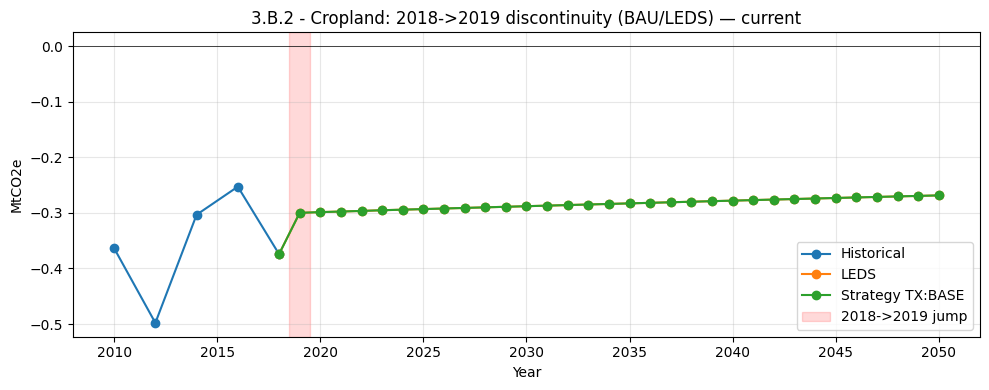

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
for strat, grp in crop.groupby('strategy'):
    ax.plot(grp['Year'], grp['value'], marker='o', label=strat)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvspan(2018.5, 2019.5, alpha=0.15, color='red', label='2018->2019 jump')
ax.set_xlabel('Year'); ax.set_ylabel('MtCO2e')
ax.set_title('3.B.2 - Cropland: 2018->2019 discontinuity (BAU/LEDS) — current')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1b) Affected Markov variables — `pij_lndu_*_to_croplands` by year

In [28]:
pij_to_crop = sorted([c for c in df.columns if c.startswith('pij_lndu_') and c.endswith('_to_croplands')])
view = (df[df['year'].between(2015, 2021)]
        .set_index('year')[pij_to_crop]
        .T)
print('pij_lndu_*_to_croplands by year (active input):')
print(view.to_string(float_format=lambda v: f'{v:.6f}'))

pij_lndu_*_to_croplands by year (active input):
year                                        2015     2016     2017     2018     2019     2020     2021
pij_lndu_croplands_to_croplands         0.989412 0.994698 0.993269 0.992645 0.992019 0.992019 0.992019
pij_lndu_flooded_to_croplands           0.000570 0.010073 0.007134 0.006236 0.005337 0.005337 0.005337
pij_lndu_forests_mangroves_to_croplands 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000
pij_lndu_forests_primary_to_croplands   0.000049 0.010123 0.005076 0.004944 0.004812 0.004812 0.004812
pij_lndu_forests_secondary_to_croplands 0.000000 0.010355 0.008679 0.007345 0.006011 0.006011 0.006011
pij_lndu_grasslands_to_croplands        0.000001 0.007266 0.004953 0.004417 0.003881 0.003881 0.003881
pij_lndu_other_to_croplands             0.000000 0.004479 0.003959 0.003309 0.002659 0.002659 0.002659
pij_lndu_pastures_to_croplands          0.000002 0.012503 0.007085 0.006608 0.006131 0.006131 0.006131
pij_lndu_settlements_to_c

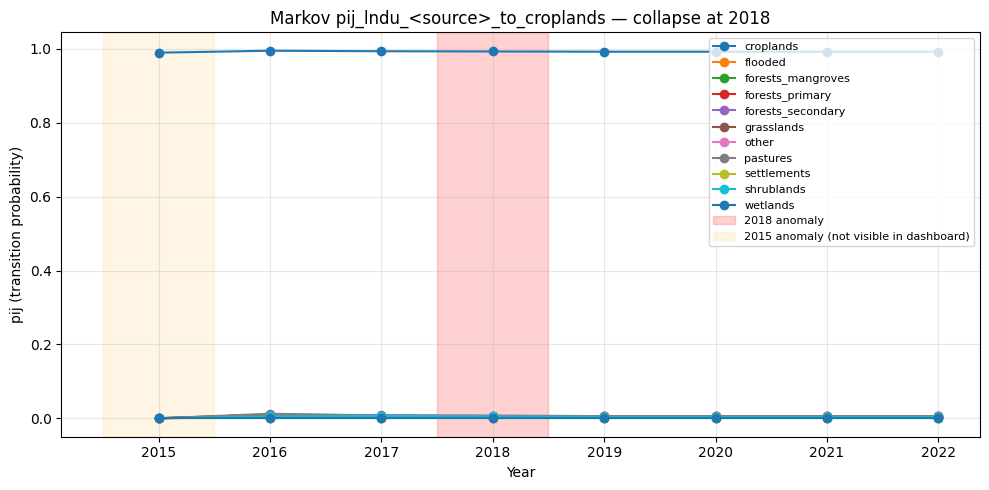

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
for c in pij_to_crop:
    src = c.replace('pij_lndu_', '').replace('_to_croplands', '')
    sub = df[df['year'].between(2015, 2022)]
    ax.plot(sub['year'], sub[c], marker='o', label=src)
ax.axvspan(2017.5, 2018.5, alpha=0.18, color='red', label='2018 anomaly')
ax.axvspan(2014.5, 2015.5, alpha=0.10, color='orange', label='2015 anomaly (not visible in dashboard)')
ax.set_xlabel('Year'); ax.set_ylabel('pij (transition probability)')
ax.set_title('Markov pij_lndu_<source>_to_croplands — collapse at 2018')
ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1c) Verification: the 2018 mass was redirected to `to_shrublands`

Compare `to_croplands` vs `to_shrublands` per source between 2017, 2018 and 2019. The mass missing from `to_croplands` reappears in `to_shrublands`.

In [30]:
SOURCES = ['forests_secondary', 'forests_primary', 'shrublands', 'grasslands',
           'pastures', 'croplands', 'flooded', 'other', 'settlements']
rows = []
for src in SOURCES:
    c_crop = f'pij_lndu_{src}_to_croplands'
    c_shrub = f'pij_lndu_{src}_to_shrublands'
    if c_crop not in df.columns or c_shrub not in df.columns:
        continue
    for y in [2017, 2018, 2019]:
        v = df[df['year'] == y].iloc[0]
        rows.append({'source': src, 'year': y,
                     'to_croplands': v[c_crop], 'to_shrublands': v[c_shrub]})
comp = pd.DataFrame(rows).pivot(index='source', columns='year').round(6)
print(comp.to_string())

                  to_croplands                     to_shrublands                    
year                      2017      2018      2019          2017      2018      2019
source                                                                              
croplands             0.993269  0.992645  0.992019      0.000000  0.000363  0.000726
flooded               0.007134  0.006236  0.005337      0.000031  0.000020  0.000010
forests_primary       0.005076  0.004944  0.004812      0.000033  0.001479  0.002924
forests_secondary     0.008679  0.007345  0.006011      0.000000  0.001447  0.002893
grasslands            0.004953  0.004417  0.003881      0.000001  0.001002  0.002003
other                 0.003959  0.003309  0.002659      0.000000  0.000141  0.000283
pastures              0.007085  0.006608  0.006131      0.000001  0.001137  0.002272
settlements           0.000000  0.000000  0.000000      0.000000  0.001040  0.002079
shrublands            0.006667  0.005225  0.003784      0.983949 

In [31]:
all_pij = [c for c in df.columns if c.startswith('pij_lndu_')]
from_states = sorted({c.replace('pij_lndu_', '').split('_to_')[0] for c in all_pij})

summary = []
for s in from_states:
    cols = [c for c in all_pij if c.startswith(f'pij_lndu_{s}_to_')]
    for y in [2017, 2018, 2019]:
        rs = df[df['year'] == y][cols].sum(axis=1).iloc[0]
        summary.append({'from': s, 'year': y, 'row_sum': rs})
row_sums = pd.DataFrame(summary).pivot(index='from', columns='year', values='row_sum')
print('Markov row sum before the fix (must be ~1.0 in every year):')
print(row_sums.to_string(float_format=lambda v: f'{v:.6f}'))

Markov row sum before the fix (must be ~1.0 in every year):
year                  2017     2018     2019
from                                        
croplands         1.000000 1.000000 0.999998
flooded           0.999875 1.000000 0.999954
forests_mangroves 1.000000 1.000000 1.000000
forests_primary   1.000000 1.000000 0.999986
forests_secondary 0.999994 1.000000 0.999995
grasslands        1.000000 1.000000 0.999993
other             0.999998 1.000000 0.999998
pastures          1.000000 1.000000 0.999992
settlements       1.000000 1.000000 1.000000
shrublands        0.999994 1.000000 0.999995
wetlands          0.000000 0.000000 0.000000


## 2) Apply the fix

For year 2018 (`time_period == 3`), replace **all** `pij_lndu_*` columns with the arithmetic mean of the 2017 and 2019 values (per column), then renormalize each row so it sums exactly to 1.0.

> **Note:** If you have already applied the fix (i.e. you ran the save cell with `APPLY=True`), the input CSV no longer contains the broken 2018 row. Re-running this cell on a fixed CSV is idempotent: it will produce a row that is the mean of 2017 and 2019, which equals (within rounding) the already-fixed 2018 row.

In [32]:
df_fixed = df.copy()
TARGET_YEAR = 2018

row_2017 = df.loc[df['year'] == 2017, all_pij].iloc[0]
row_2019 = df.loc[df['year'] == 2019, all_pij].iloc[0]
row_new = (row_2017 + row_2019) / 2.0

for s in from_states:
    cols = [c for c in all_pij if c.startswith(f'pij_lndu_{s}_to_')]
    rs = row_new[cols].sum()
    if rs > 0:
        row_new[cols] = row_new[cols] / rs

df_fixed.loc[df_fixed['year'] == TARGET_YEAR, all_pij] = row_new[all_pij].values
print(f'Replaced the {TARGET_YEAR} Markov row with the (2017, 2019) mean, renormalized.')

Replaced the 2018 Markov row with the (2017, 2019) mean, renormalized.


## 3) Verification AFTER the fix

In [33]:
summary_after = []
for s in from_states:
    cols = [c for c in all_pij if c.startswith(f'pij_lndu_{s}_to_')]
    for y in [2017, 2018, 2019]:
        rs = df_fixed[df_fixed['year'] == y][cols].sum(axis=1).iloc[0]
        summary_after.append({'from': s, 'year': y, 'row_sum': rs})
row_sums_after = pd.DataFrame(summary_after).pivot(index='from', columns='year', values='row_sum')
print('Markov row sums AFTER the fix:')
print(row_sums_after.to_string(float_format=lambda v: f'{v:.6f}'))

assert (row_sums_after.loc[:, 2018].between(0.999, 1.001) | (row_sums_after.loc[:, 2018] == 0)).all(), \
    'A 2018 Markov row does not sum to 1 (0 allowed for empty rows like wetlands)'
print('\nStochastic rows: OK.')

Markov row sums AFTER the fix:
year                  2017     2018     2019
from                                        
croplands         1.000000 1.000000 0.999998
flooded           0.999875 1.000000 0.999954
forests_mangroves 1.000000 1.000000 1.000000
forests_primary   1.000000 1.000000 0.999986
forests_secondary 0.999994 1.000000 0.999995
grasslands        1.000000 1.000000 0.999993
other             0.999998 1.000000 0.999998
pastures          1.000000 1.000000 0.999992
settlements       1.000000 1.000000 1.000000
shrublands        0.999994 1.000000 0.999995
wetlands          0.000000 0.000000 0.000000

Stochastic rows: OK.


In [34]:
view_after = (df_fixed[df_fixed['year'].between(2015, 2021)]
              .set_index('year')[pij_to_crop]
              .T)
print('pij_lndu_*_to_croplands by year AFTER the fix:')
print(view_after.to_string(float_format=lambda v: f'{v:.6f}'))

pij_lndu_*_to_croplands by year AFTER the fix:
year                                        2015     2016     2017     2018     2019     2020     2021
pij_lndu_croplands_to_croplands         0.989412 0.994698 0.993269 0.992645 0.992019 0.992019 0.992019
pij_lndu_flooded_to_croplands           0.000570 0.010073 0.007134 0.006236 0.005337 0.005337 0.005337
pij_lndu_forests_mangroves_to_croplands 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000 0.000000
pij_lndu_forests_primary_to_croplands   0.000049 0.010123 0.005076 0.004944 0.004812 0.004812 0.004812
pij_lndu_forests_secondary_to_croplands 0.000000 0.010355 0.008679 0.007345 0.006011 0.006011 0.006011
pij_lndu_grasslands_to_croplands        0.000001 0.007266 0.004953 0.004417 0.003881 0.003881 0.003881
pij_lndu_other_to_croplands             0.000000 0.004479 0.003959 0.003309 0.002659 0.002659 0.002659
pij_lndu_pastures_to_croplands          0.000002 0.012503 0.007085 0.006608 0.006131 0.006131 0.006131
pij_lndu_settlements_to_cr

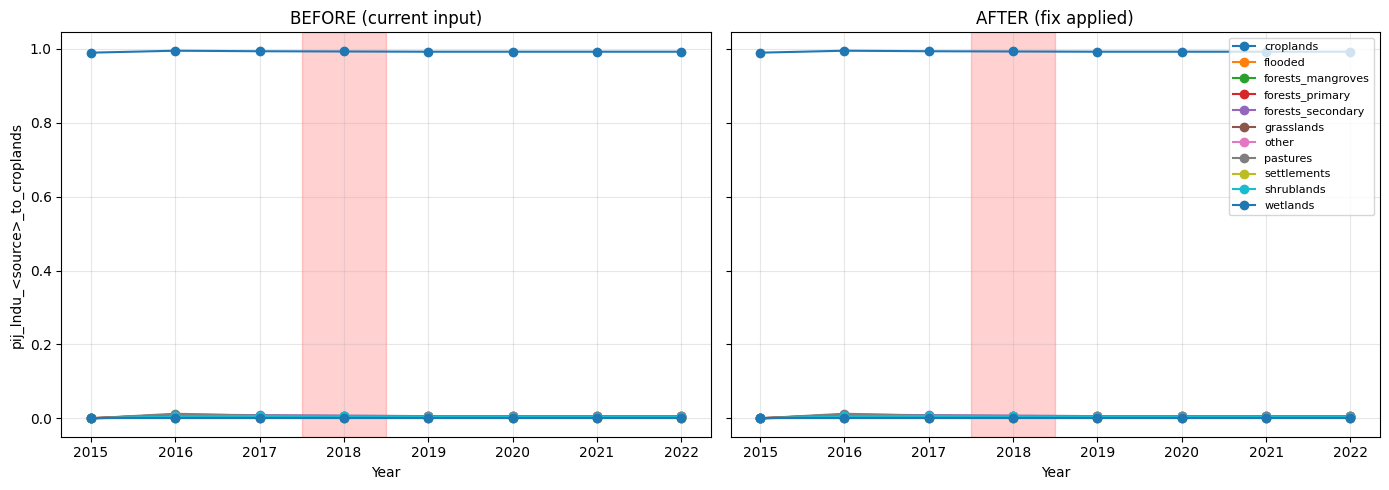

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for c in pij_to_crop:
    src = c.replace('pij_lndu_', '').replace('_to_croplands', '')
    sub_b = df[df['year'].between(2015, 2022)]
    sub_a = df_fixed[df_fixed['year'].between(2015, 2022)]
    axes[0].plot(sub_b['year'], sub_b[c], marker='o', label=src)
    axes[1].plot(sub_a['year'], sub_a[c], marker='o', label=src)
for ax, title in zip(axes, ['BEFORE (current input)', 'AFTER (fix applied)']):
    ax.axvspan(2017.5, 2018.5, alpha=0.18, color='red')
    ax.set_xlabel('Year'); ax.set_title(title); ax.grid(alpha=0.3)
axes[0].set_ylabel('pij_lndu_<source>_to_croplands')
axes[1].legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 4) Save (with backup)

Set `APPLY = True` and re-run the cell to overwrite the active input. A `.bak_<timestamp>` is created first.

Once applied, **re-run the model** (`run_calibration.py`) and refresh Tableau to verify the 3.B.2 jump 2018->2019 is gone.

In [36]:
APPLY = True  

if APPLY:
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    backup = ACTIVE_CSV.with_suffix(f'.csv.bak_{ts}')
    shutil.copy2(ACTIVE_CSV, backup)
    df_fixed.to_csv(ACTIVE_CSV, index=False)
    print(f'Backup -> {backup.name}')
    print(f'Wrote  -> {ACTIVE_CSV.name}')

    reloaded = pd.read_csv(ACTIVE_CSV, usecols=pij_to_crop + ['year'])
    chk = reloaded[reloaded['year'] == 2018][pij_to_crop].iloc[0]
    print(f'\nReload check — sum(pij_lndu_*_to_croplands) in 2018: {chk.sum():.6f}')
    print('  (was ~0 before the fix; should now be >0 and consistent with 2017/2019)')
else:
    print('APPLY=False — set APPLY=True to write the file.')

Backup -> sisepuede_raw_inputs_recalibrated_electricity_trns_improved_cement.csv.bak_20260520_151708
Wrote  -> sisepuede_raw_inputs_recalibrated_electricity_trns_improved_cement.csv

Reload check — sum(pij_lndu_*_to_croplands) in 2018: 1.030729
  (was ~0 before the fix; should now be >0 and consistent with 2017/2019)


## 5) Notes and follow-ups

- **Year 2015**: has the same anomaly. It does not visually affect the dashboard because the historical panel uses NIR up to 2018, but **it does affect the model's LULUCF area trajectory from t=0**. If residual oscillations appear at the start of the horizon after rerunning, extend the fix by copying the 2016 row over 2015 (there is no 2014 to interpolate from).
- **Other LULUCF subsectors (3.B.3, 3.B.6)**: the same jump may show up in grasslands and shrublands because the 2018 mass that should have gone to cropland was redirected to those classes. After this fix, also validate those subsectors in the dashboard.
- **Bug origin**: the 2018 (and 2015) anomaly is very systematic — it looks suspiciously like a `to_croplands`<>`to_shrublands` column swap during historical-matrix construction in `apply_step0_verified.py` / `apply_step1_calibration.py`. Worth auditing those scripts before closing the ticket.
- The `ef_lndu_*` emission factors are **not** modified — the issue is confined to the transition matrix.